In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sakshichaudhary91/placement-iqr/placement.csv


**Outlier Detection using IQR**

use when data is skewed distributed.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sakshichaudhary91/placement-iqr/placement.csv')

In [4]:
df.shape

(1000, 3)

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
674,6.73,31.0,1
936,7.32,20.0,0
719,7.17,26.0,0
9,7.75,94.0,1
603,6.55,54.0,1


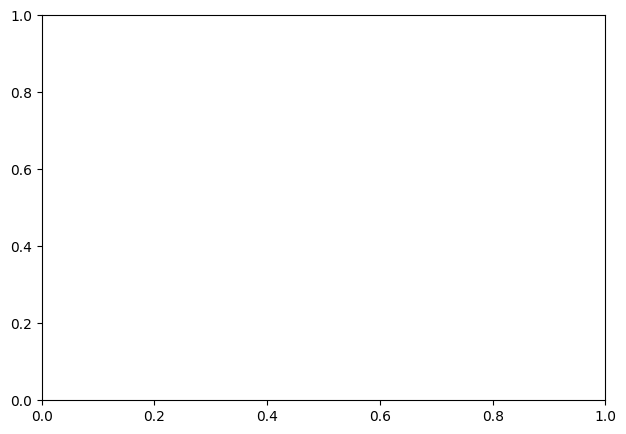

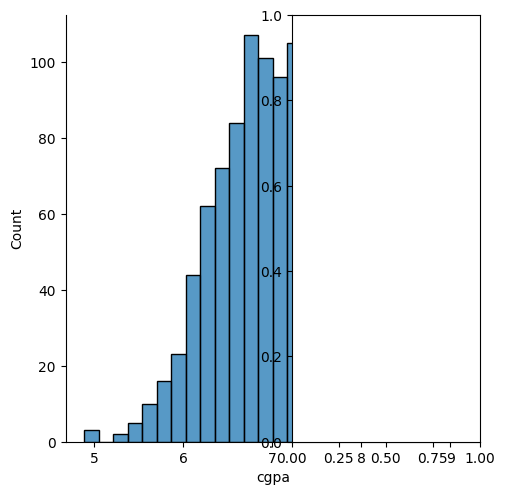

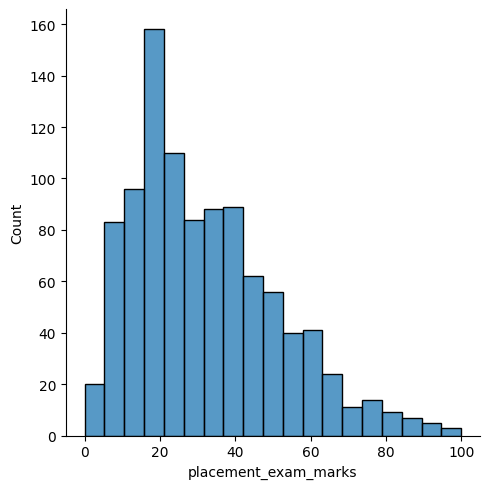

In [6]:
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.displot(df['cgpa'])
plt.subplot(1,2,2)
sns.displot(df['placement_exam_marks'])
plt.show()

In [7]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

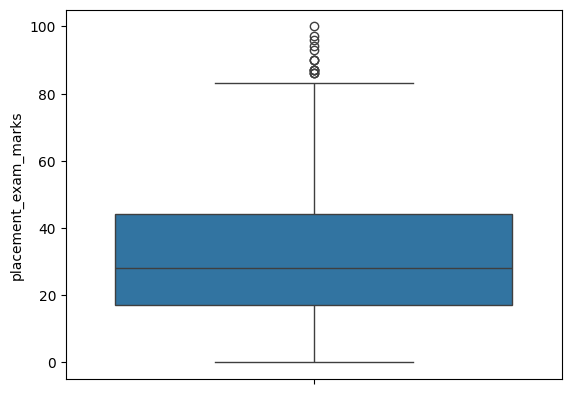

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [10]:
#Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [11]:
percentile75

np.float64(44.0)

In [12]:
iqr = percentile75 - percentile25

In [13]:
iqr

np.float64(27.0)

In [14]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [15]:
print("Upper limit", upper_limit)
print("Lower limit", lower_limit)

Upper limit 84.5
Lower limit -23.5


**Finding Outliers**

In [16]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [17]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


**Trimming**

In [18]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [19]:
new_df.shape

(985, 3)

**Comparing**

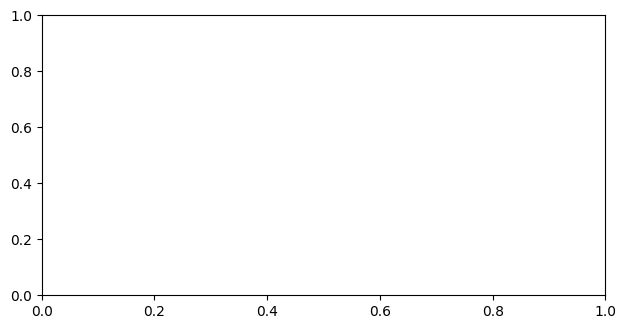

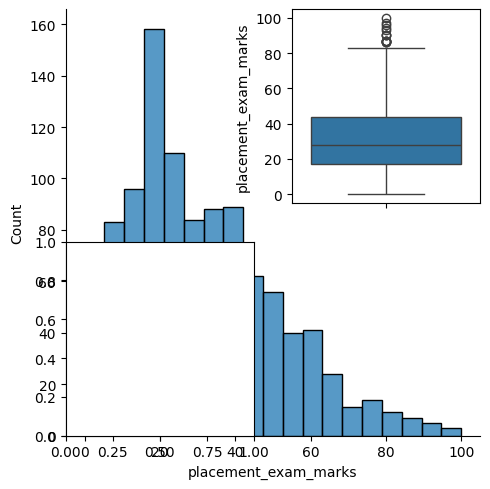

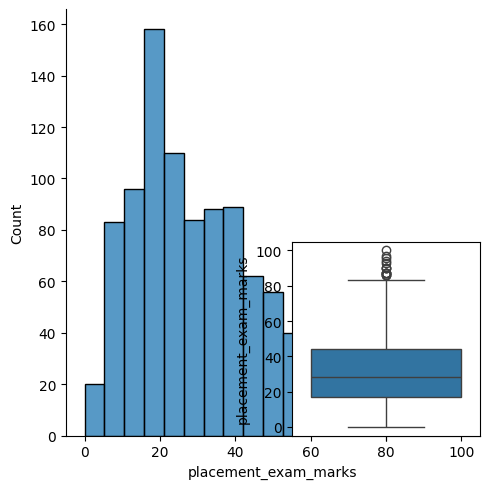

In [20]:
plt.figure(figsize = (16,8))
plt.subplot(2,2,1)
sns.displot(df['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.displot(df['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(df['placement_exam_marks'])
plt.show()


**Capping**

In [21]:
new_df_cap = df.copy()
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [22]:
new_df_cap.shape

(1000, 3)

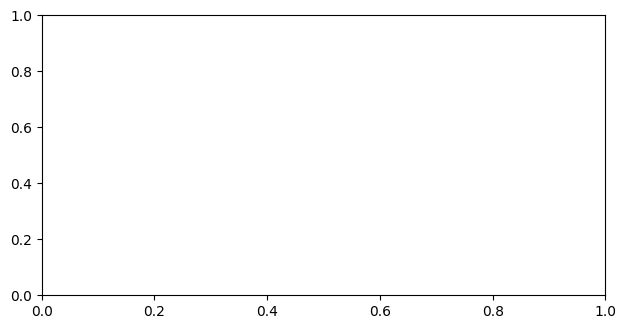

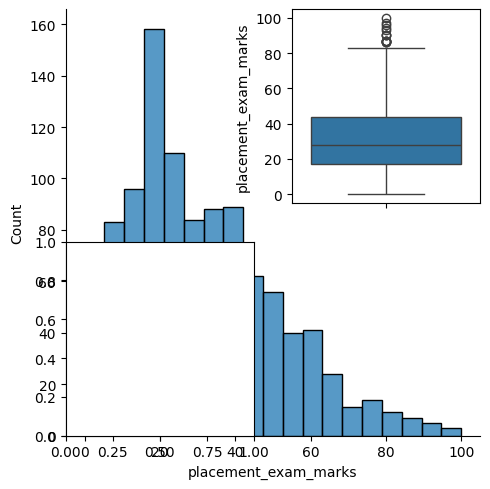

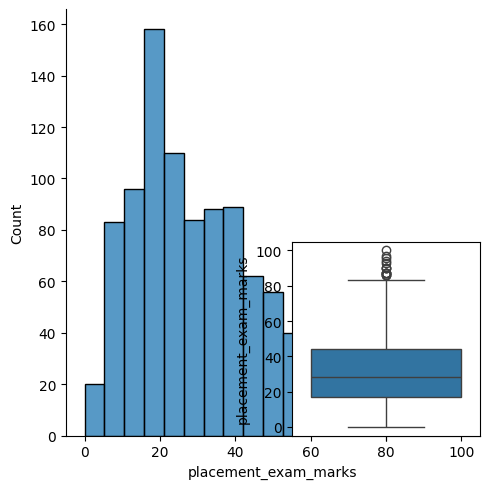

In [23]:
plt.figure(figsize = (16,8))
plt.subplot(2,2,1)
sns.displot(df['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.displot(df['placement_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(df['placement_exam_marks'])
plt.show()
